## Session 1: Prompt Chaining

In [4]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv

In [5]:
load_dotenv()

model = ChatOpenAI(model = "gpt-5.4-mini-2026-03-17" , temperature = 0)
# model = ChatOpenAI(
#     model="openai/gpt-5.4-mini",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
#     temperature=0,
# )

In [6]:
class BlogState(TypedDict):

    title: str
    outline: str
    content: str

In [7]:
def create_outline(state: BlogState) -> BlogState:

    # fetch title
    title = state['title']

    # call llm gen outline
    prompt = f'Generate a detailed outline for a blog on the topic - {title}. Dont put anything else apart from this'
    outline = model.invoke(prompt).content

    # update state
    state['outline'] = outline

    return state

In [8]:
def create_blog(state: BlogState) -> BlogState:

    title = state['title']
    outline = state['outline']

    prompt = f'Write a detailed blog on the title - {title} using the follwing outline \n {outline}. Dont put anything else apart from this'

    content = model.invoke(prompt).content

    state['content'] = content

    return state

In [9]:
graph = StateGraph(BlogState)

# nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

# edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

workflow = graph.compile()

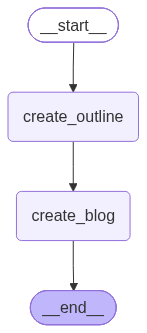

In [10]:
workflow

In [11]:
intial_state = {'title': 'Rise of AI in India'}

final_state = workflow.invoke(intial_state)

print(final_state)

{'title': 'Rise of AI in India', 'outline': '1. Introduction  \n   1.1 Defining Artificial Intelligence  \n   1.2 Why AI is becoming important in India  \n   1.3 Scope of AI growth across industries  \n\n2. The Current AI Landscape in India  \n   2.1 Overview of AI adoption in the country  \n   2.2 Key sectors using AI today  \n   2.3 Major cities and innovation hubs driving AI growth  \n\n3. Factors Driving the Rise of AI in India  \n   3.1 Digital transformation and internet penetration  \n   3.2 Availability of large data sets  \n   3.3 Government support and policy initiatives  \n   3.4 Growth of startups and tech ecosystem  \n   3.5 Demand for automation and efficiency  \n\n4. Government Initiatives and Policies  \n   4.1 National AI strategy and vision  \n   4.2 Digital India and related programs  \n   4.3 AI-focused research and development support  \n   4.4 Skill development and talent-building initiatives  \n\n5. AI Applications Across Major Industries  \n   5.1 Healthcare  \n

In [12]:
print(final_state['outline'])

1. Introduction  
   1.1 Defining Artificial Intelligence  
   1.2 Why AI is becoming important in India  
   1.3 Scope of AI growth across industries  

2. The Current AI Landscape in India  
   2.1 Overview of AI adoption in the country  
   2.2 Key sectors using AI today  
   2.3 Major cities and innovation hubs driving AI growth  

3. Factors Driving the Rise of AI in India  
   3.1 Digital transformation and internet penetration  
   3.2 Availability of large data sets  
   3.3 Government support and policy initiatives  
   3.4 Growth of startups and tech ecosystem  
   3.5 Demand for automation and efficiency  

4. Government Initiatives and Policies  
   4.1 National AI strategy and vision  
   4.2 Digital India and related programs  
   4.3 AI-focused research and development support  
   4.4 Skill development and talent-building initiatives  

5. AI Applications Across Major Industries  
   5.1 Healthcare  
   5.2 Agriculture  
   5.3 Education  
   5.4 Banking and financial s

In [13]:
print(final_state['content'])

# Rise of AI in India

## 1. Introduction

Artificial Intelligence, or AI, is no longer a futuristic concept reserved for science fiction. It has become one of the most powerful technologies shaping the modern world, and India is emerging as one of its fastest-growing markets. From healthcare and finance to agriculture and education, AI is transforming how businesses operate, how governments deliver services, and how people interact with technology.

### 1.1 Defining Artificial Intelligence

Artificial Intelligence refers to the ability of machines and computer systems to perform tasks that typically require human intelligence. These tasks include learning from data, recognizing patterns, understanding language, making decisions, and solving problems. AI powers tools such as chatbots, recommendation systems, fraud detection software, voice assistants, image recognition, and predictive analytics.

AI is broadly divided into several areas, including machine learning, natural language pro

## Quick Task: Professional Email Writer ( 10 mins)

Build a sequential workflow that:

1. Takes a `topic`
2. Generates `bullet_points` for the email
3. Writes a `email` using those bullet points

**Hints**
- State fields: `topic`, `bullet_points`, `email`
- Two nodes, sequential edges: `START → create_bullets → write_email → END`
- Node 2 must use both `topic` and `bullet_points`
- Try `{'topic': 'Follow up after a job interview for a data scientist role'}`

Fill in the cells below.

In [ ]:
# define state
class EmailState(TypedDict):
    ...

In [ ]:
# node 1: generate bullet points from the topic
def create_bullets(state: EmailState) -> EmailState:
    ...

In [ ]:
# node 2: write the email using topic + bullet_points
def write_email(state: EmailState) -> EmailState:
    ...

In [ ]:
# define your graph, add nodes + edges, compile
# START → create_bullets → write_email → END

In [ ]:
workflow

In [ ]:
# execute the graph
# initial_state = {'topic': 'Follow up after a job interview for a data scientist role'}